# Logistic Regression With Imbalance Dataset

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, StratifiedGroupKFold
from collections import Counter

## Imbalance dataset


In [22]:
X, y = make_classification(n_samples=10000, n_features= 2, n_clusters_per_class=1, n_redundant=0, weights=[0.99], random_state=10)

In [23]:
pd.DataFrame(X).head()

,0,1
0,1.879910,-1.485035
1,0.377083,-2.238585
2,1.354312,-2.664638
3,-0.509843,-1.502950
4,0.863561,-1.906364


In [24]:
pd.DataFrame(y).value_counts()

0
0    9846
1     154
Name: count, dtype: int64

Here you can see that our model is highly imbalance 

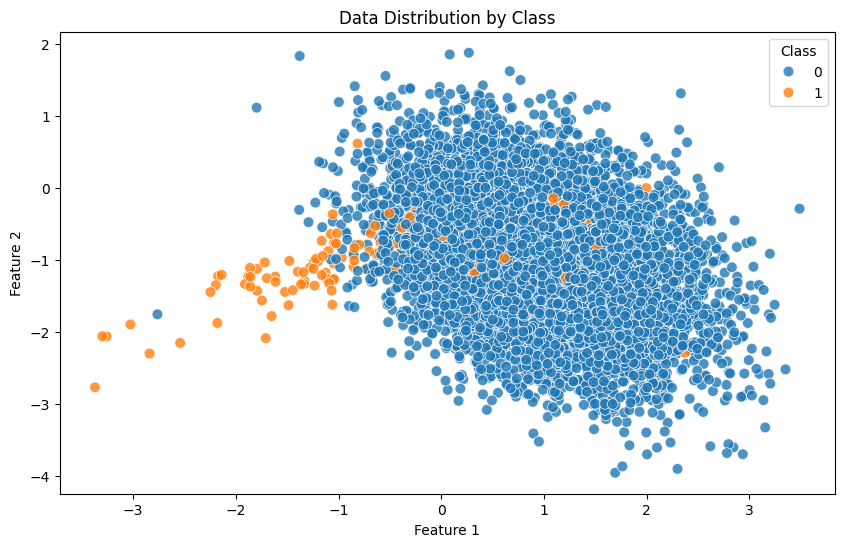

In [25]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=pd.DataFrame(X)[0], y=pd.DataFrame(X)[1], hue=y, s=60, alpha=0.8)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2') 
plt.title('Data Distribution by Class')
plt.legend(title='Class')
plt.show()

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=12)

In [27]:
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


In [28]:
print(accuracy_score(y_test, y_pred))

0.9863333333333333


In [29]:
print(confusion_matrix(y_test, y_pred))

[[2949    0]
 [  41   10]]


In [30]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2949
           1       1.00      0.20      0.33        51

    accuracy                           0.99      3000
   macro avg       0.99      0.60      0.66      3000
weighted avg       0.99      0.99      0.98      3000



## Hyperparameter Tuning

In [ ]:
# model = LogisticRegression()

# # This creates various ratios for the binary classes {0: w, 1: y}.

# class_weights = [{0: w, 1: y} for w in [1, 10, 50, 100] for y in [1, 10, 50, 100] if w != y]
# class_weights.insert(0, None)


# params = [
#     # Grid for solvers that only support L2 penalty
#     {
#         'solver': ['newton-cg', 'lbfgs', 'sag'],
#         'penalty': ['l2'],
#         'C': [100, 10, 1, 0.1, 0.01],
#         'class_weight': class_weights
#     },
#     # Grid for liblinear (supports L1 and L2)
#     {
#         'solver': ['liblinear'],
#         'penalty': ['l1', 'l2'],
#         'C': [100, 10, 1, 0.1, 0.01],
#         'class_weight': class_weights
#     },
#     # Grid for saga (supports L1, L2, and elasticnet)
#     {
#         'solver': ['saga'],
#         'penalty': ['l1', 'l2', 'elasticnet'],
#         'C': [100, 10, 1, 0.1, 0.01],
#         'class_weight': class_weights,
#     }
# ]


# --- Corrected Hyperparameter Grid (Cell 11) ---
model = LogisticRegression(max_iter=1000) # Increased max_iter to avoid convergence warnings

# This creates various ratios for the binary classes {0: w, 1: y}.
class_weights = [{0: w, 1: y} for w in [1, 10] for y in [1, 10] if w != y]
class_weights.insert(0, None)

# Corrected params to include l1_ratio for the 'saga' solver
params = [
    {
        'solver': ['newton-cg', 'lbfgs', 'sag'],
        'penalty': ['l2'],
        'C': [100, 10, 1, 0.1, 0.01],
        'class_weight': class_weights
    },
    {
        'solver': ['liblinear'],
        'penalty': ['l1', 'l2'],
        'C': [100, 10, 1, 0.1, 0.01],
        'class_weight': class_weights
    },
    {
        'solver': ['saga'],
        'penalty': ['l1', 'l2', 'elasticnet'],
        'C': [100, 10, 1, 0.1, 0.01],
        'class_weight': class_weights,
        'l1_ratio': np.linspace(0, 1, 5)  # Added l1_ratio for elasticnet penalty
    }
]

In [32]:
params  # the class weight created all the combination for the calculation

[{'solver': ['newton-cg', 'lbfgs', 'sag'],
  'penalty': ['l2'],
  'C': [100, 10, 1, 0.1, 0.01],
  'class_weight': [None,
   {0: 1, 1: 10},
   {0: 1, 1: 50},
   {0: 10, 1: 1},
   {0: 10, 1: 50},
   {0: 50, 1: 1},
   {0: 50, 1: 10}]},
 {'solver': ['liblinear'],
  'penalty': ['l1', 'l2'],
  'C': [100, 10, 1, 0.1, 0.01],
  'class_weight': [None,
   {0: 1, 1: 10},
   {0: 1, 1: 50},
   {0: 10, 1: 1},
   {0: 10, 1: 50},
   {0: 50, 1: 1},
   {0: 50, 1: 10}]},
 {'solver': ['saga'],
  'penalty': ['l1', 'l2', 'elasticnet'],
  'C': [100, 10, 1, 0.1, 0.01],
  'class_weight': [None,
   {0: 1, 1: 10},
   {0: 1, 1: 50},
   {0: 10, 1: 1},
   {0: 10, 1: 50},
   {0: 50, 1: 1},
   {0: 50, 1: 10}],
  'l1_ratio': array([0.  , 0.25, 0.5 , 0.75, 1.  ])}]

In [33]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
# cv = StratifiedKFold(n_splits=5)

grid = GridSearchCV(estimator=model, param_grid=params, scoring='accuracy', n_jobs=-1, verbose=1)


In [34]:
grid.fit(X_train, y_train)

Fitting 5 folds for each of 700 candidates, totalling 3500 fits


GridSearchCV(estimator=LogisticRegression(max_iter=1000), n_jobs=-1,
             param_grid=[{'C': [100, 10, 1, 0.1, 0.01],
                          'class_weight': [None, {0: 1, 1: 10}, {0: 1, 1: 50},
                                           {0: 10, 1: 1}, {0: 10, 1: 50},
                                           {0: 50, 1: 1}, {0: 50, 1: 10}],
                          'penalty': ['l2'],
                          'solver': ['newton-cg', 'lbfgs', 'sag']},
                         {'C': [100, 10, 1, 0.1, 0.01],
                          'class_weight': [None, {0: 1, 1: 10}, {0: 1, 1: 50},
                                           {0: 10, 1: 1}, {0: 10, 1: 50},
                                           {0: 50, 1: 1}, {0: 50, 1: 10}],
                          'penalty': ['l1', 'l2'], 'solver': ['liblinear']},
                         {'C': [100, 10, 1, 0.1, 0.01],
                          'class_weight': [None, {0: 1, 1: 10}, {0: 1, 1: 50},
                                           {0: 10, 1: 1}, {0: 10, 1: 50},
                                           {0: 50, 1: 1}, {0: 50, 1: 10}],
                          'l1_ratio': array([0.  , 0.25, 0.5 , 0.75, 1.  ]),
                          'penalty': ['l1', 'l2', 'elasticnet'],
                          'solver': ['saga']}],
             scoring='accuracy', verbose=1)

In [35]:
X_train

array([[ 0.21596343, -0.35255065],
       [ 0.14182204, -0.10356058],
       [ 1.62029611, -0.69982329],
       ...,
       [ 2.8205112 , -1.90168387],
       [-0.13599796, -1.3660373 ],
       [ 0.38278515, -1.09135159]])

In [36]:
grid.best_params_

{'C': 0.01,
 'class_weight': {0: 10, 1: 50},
 'penalty': 'l2',
 'solver': 'newton-cg'}

In [37]:
y_pred = grid.predict(X_test)

In [38]:
acc = accuracy_score(y_test, y_pred)
print(acc)
con = confusion_matrix(y_test, y_pred)
print(con)

0.986
[[2943    6]
 [  36   15]]


In [39]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2949
           1       0.71      0.29      0.42        51

    accuracy                           0.99      3000
   macro avg       0.85      0.65      0.70      3000
weighted avg       0.98      0.99      0.98      3000



In [40]:
grid.best_score_

0.9902857142857142